# Labor 1 — toore signaali spekter ja müra

MPX5700AP → AtomS3R ADC otse (ei jagurit, ei op-ampi). Logija 100 Hz, `t_ms, adc[, p_kpa, pump]`.

Andmed (mõõdetud 13.09.26, failid `../data/`):
- `lab1_lsb_noise_vacuum_button_13.09.26.csv` — 10 s logi: atmosfäär, siis pumbakasti nupp, vaakum hoiab.
- `lab1_autonomous_run_13.09.26.csv` — autonoomne jooks, 8 pumba tsüklit (`pump` = 0/1).

**Piirangud (loe enne graafikuid):**
- Diskreetimine 100 Hz → nähtav sagedusala on ainult 0–50 Hz (Nyquist). 50 Hz võrgumüra on täpselt Nyquisti piiril ja laskub (aliasing); pumba mootori kommutatsioon (kHz) ei ole selle logiga nähtav.
- Pumba töölõigud on lühikesed (~1,5 s = ~150 punkti), seega on pumba-sees spekter jäme.
- Tippude nimeline kinnitamine ei ole selles laboris nõutud (õppejõud, 02.10.26; vt `../README.md`). Ostsilloskoobi katse: `../docs/sensor_choice.md`.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.signal import welch, detrend

V_REF = 3.70            # mõõdetud Atomi ADC viitepinge, V (docs/sensor_choice.md)
FS = 100.0              # Hz, logija samm 10 ms
# MPX5700AP: Vout = 5 * (0.0012858 * P + 0.04), P kPa absoluutne
pa_per_lsb = V_REF / 4095 / (5 * 0.0012858) * 1000
print(f"Pa ühe ADC sammu kohta: {pa_per_lsb:.0f} Pa/LSB")

Pa ühe ADC sammu kohta: 141 Pa/LSB


## 1. Atmosfäär vs hoitud vaakum (pump seisab mõlemas)

In [2]:
n = pd.read_csv('../data/lab1_lsb_noise_vacuum_button_13.09.26.csv')
assert (n.t_ms.diff().dropna() == 10).all()
x = n.adc.to_numpy(float)
# samad aknad nagu docs/sensor_choice.md tabelis (13.09.26): esimesed 272 punkti enne nuppu,
# viimased 401 punkti hoitud vaakumis; üleminek (~190 ms) ja selle saba jäävad välja
atm, vac = x[:272], x[-401:]
for name, s in [('atmosfäär', atm), ('vaakum hoitud', vac)]:
    print(f"{name:14s} N={len(s):4d}  keskm {s.mean():6.1f}  std {s.std(ddof=1):.2f} LSB = {s.std(ddof=1)*pa_per_lsb:.0f} Pa  min–max {s.min():.0f}–{s.max():.0f}")

atmosfäär      N= 272  keskm  941.6  std 4.85 LSB = 682 Pa  min–max 930–954
vaakum hoitud  N= 401  keskm  361.1  std 3.69 LSB = 518 Pa  min–max 349–372


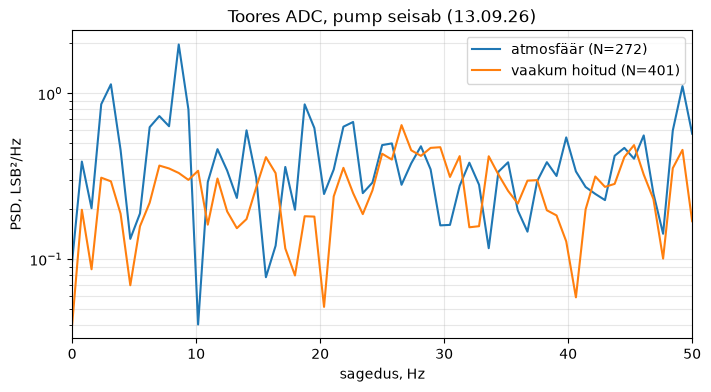

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
for name, x in [('atmosfäär', atm), ('vaakum hoitud', vac)]:
    f, p = welch(x - x.mean(), fs=FS, nperseg=128)
    ax.semilogy(f, p, label=f'{name} (N={len(x)})')
ax.set_xlabel('sagedus, Hz'); ax.set_ylabel('PSD, LSB²/Hz'); ax.set_xlim(0, 50)
ax.set_title('Toores ADC, pump seisab (13.09.26)'); ax.grid(True, which='both', alpha=.3); ax.legend()
plt.show()

## 2. Autonoomne jooks: pump sees vs pump väljas

Rõhk muutub kogu aeg (pumpamine, leke), seega eemaldatakse aeglane osa liikuva mediaaniga (25 punkti = 0,25 s) ja jääb müra. See tähendab ka, et alla ~4 Hz on spekter summutatud — seda ala siit ei loe.

In [4]:
a = pd.read_csv('../data/lab1_autonomous_run_13.09.26.csv')
assert (a.t_ms.diff().dropna() == 10).all()
x = a.adc.astype(float)
noise = (x - x.rolling(25, center=True).median()).to_numpy()
seg_id = (a.pump.diff() != 0).cumsum().to_numpy()
psd = {0: [], 1: []}; resid = {0: [], 1: []}
for sid in np.unique(seg_id):
    m = seg_id == sid
    r = noise[m]; r = r[~np.isnan(r)]
    if len(r) < 128:            # liiga lühike lõik Welchi jaoks
        continue
    k = int(a.pump[m].iloc[0])
    resid[k].append(r)
    f, p = welch(r - r.mean(), fs=FS, nperseg=128); psd[k].append(p)
for k, name in [(0, 'pump väljas'), (1, 'pump sees')]:
    r = np.concatenate(resid[k])
    print(f"{name:12s} lõike {len(psd[k]):2d}  N={len(r):5d}  müra std {r.std(ddof=1):.2f} LSB = {r.std(ddof=1)*pa_per_lsb:.0f} Pa")

pump väljas  lõike  9  N=12949  müra std 4.53 LSB = 636 Pa
pump sees    lõike  9  N= 1388  müra std 4.17 LSB = 586 Pa


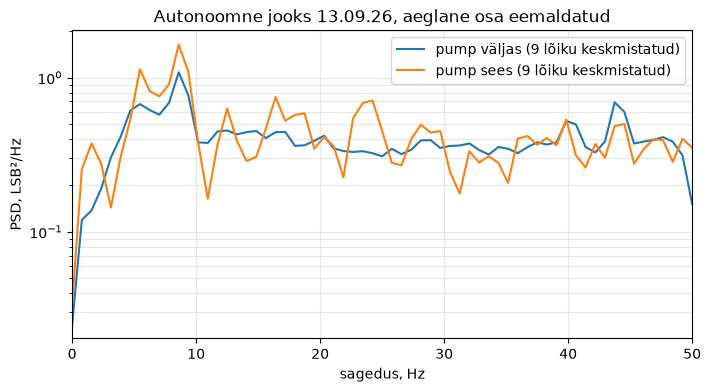

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
for k, name in [(0, 'pump väljas'), (1, 'pump sees')]:
    ax.semilogy(f, np.mean(psd[k], axis=0), label=f'{name} ({len(psd[k])} lõiku keskmistatud)')
ax.set_xlabel('sagedus, Hz'); ax.set_ylabel('PSD, LSB²/Hz'); ax.set_xlim(0, 50)
ax.set_title('Autonoomne jooks 13.09.26, aeglane osa eemaldatud'); ax.grid(True, which='both', alpha=.3); ax.legend()
plt.show()

## Järeldus

- Pa ühe ADC sammu kohta ja müra LSB-des on ülal väljundis; arvutatud samadest CSV-dest, mis on repos. Atmosfääri ja hoitud vaakumi aknad on samad mis `docs/sensor_choice.md` tabelis.
- Mõlemas autonoomse jooksu spektris (pump sees ja väljas) on küür umbes 8–9 Hz juures. Selle allikat ei kontrollitud (ühtegi allikat ei lülitatud selle jaoks välja), seega seda siin ei nimetata.
- Kõrgemad sagedused (mootori kommutatsioon, 50 Hz õigesti) vajavad kiiremat diskreetimist või ostsilloskoopi; 100 Hz logist neid ei näe.
- See fail on Labor 2 võrdluse lähtejoon: sama analüüs korratakse jaguri ja op-ampiga (`../../lab2/`).